In [3]:
import seaborn as sns
import numpy as np
import pandas as pd


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [8]:
df = pd.read_csv("titanic.csv")

In [84]:
X = df.drop(['survived'],axis = 1)
y = df['survived']

In [7]:
X_train,X_test,y_train,y_test = train_test_split(
  X,y,
  test_size=0.2,
  stratify=y,
  random_state=42
)

In [9]:
print(df['survived'].value_counts(normalize=True) * 100)

survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


**In the Titanic dataset, about 62% of passengers did not survive and about 38% survived. Since the two classes are not equally balanced, stratification is important when splitting the data. It helps keep nearly the same percentage of survivors and non-survivors in both the training and testing datasets, making the model evaluation more reliable.**

In [11]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [12]:
df['age'] = df['age'].fillna(df['age'].median())
df = df.dropna(subset=['embarked'])
df = df.dropna(subset=['embark_town'])
df['deck'] = df['deck'].fillna('missing')

In [14]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')

In [13]:
X = df[['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex', 'embarked']]
y = df['survived']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [16]:
numeric_features = ['pclass', 'age', 'sibsp', 'parch', 'fare']

categorical_features = ['sex', 'embarked']

In [30]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [18]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

In [19]:
categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [20]:
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [27]:
logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

In [28]:
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pclass','age','sibsp',...,'fare','sex','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining column

In [33]:
y_pred_logistic = logistic_model.predict(X_test)

In [31]:
tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        random_state=42,
        max_depth=4
    ))
])

In [37]:
tree_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pclass','age','sibsp',...,'fare','sex','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining column

In [32]:
forest_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [38]:
forest_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pclass','age','sibsp',...,'fare','sex','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining column

In [39]:
y_pred_tree = tree_model.predict(X_test)
y_pred_forest = forest_model.predict(X_test)

In [40]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)
import pandas as pd
import matplotlib.pyplot as plt

In [46]:
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]
y_prob_tree = tree_model.predict_proba(X_test)[:, 1]
y_prob_forest = forest_model.predict_proba(X_test)[:, 1]

In [47]:
models = {
    'Logistic Regression': (y_pred_logistic, y_prob_logistic),
    'Decision Tree': (y_pred_tree, y_prob_tree),
    'Random Forest': (y_pred_forest, y_prob_forest)
}

results = []

for name, (y_pred, y_prob) in models.items():

    cm = confusion_matrix(y_test, y_pred)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        'Model': name,
        'Confusion Matrix': cm,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'AUC': auc
    })

comparison_df = pd.DataFrame(results)

comparison_df

,Model,Confusion Matrix,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,"[[97, 13], [21, 47]]",0.808989,0.783333,0.691176,0.734375,0.860963
1,Decision Tree,"[[100, 10], [24, 44]]",0.808989,0.814815,0.647059,0.721311,0.856016
2,Random Forest,"[[96, 14], [18, 50]]",0.820225,0.781250,0.735294,0.757576,0.817914


In [48]:
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_forest, tpr_forest, _ = roc_curve(y_test, y_prob_forest)

In [49]:
auc_logistic = roc_auc_score(y_test, y_prob_logistic)
auc_tree = roc_auc_score(y_test, y_prob_tree)
auc_forest = roc_auc_score(y_test, y_prob_forest)

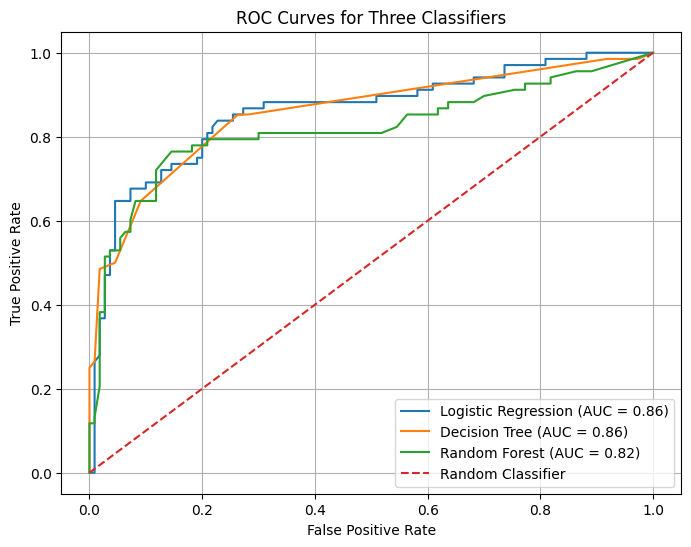

In [51]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f'Logistic Regression (AUC = {auc_logistic:.2f})'
)

plt.plot(
    fpr_tree,
    tpr_tree,
    label=f'Decision Tree (AUC = {auc_tree:.2f})'
)

plt.plot(
    fpr_forest,
    tpr_forest,
    label=f'Random Forest (AUC = {auc_forest:.2f})'
)

plt.plot([0, 1], [0, 1], linestyle='--', label='Random Classifier')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Three Classifiers')
plt.legend()
plt.grid()
plt.show()

In [52]:
print("Class counts:")
print(y.value_counts())

print("\nClass percentages:")
print((y.value_counts(normalize=True) * 100).round(2))

Class counts:
survived
0    549
1    340
Name: count, dtype: int64

Class percentages:
survived
0    61.75
1    38.25
Name: proportion, dtype: float64


In [53]:
baseline_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)

y_pred_baseline = baseline_model.predict(X_test)

In [54]:
balanced_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced'
    ))
])

balanced_model.fit(X_train, y_train)

y_pred_balanced = balanced_model.predict(X_test)

In [55]:
from imblearn.over_sampling import SMOTE
# Fit preprocessing ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the already-fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

In [56]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [57]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
survived
0    439
1    272
Name: count, dtype: int64

After SMOTE:
survived
1    439
0    439
Name: count, dtype: int64


In [58]:
smote_model = LogisticRegression(max_iter=1000)

smote_model.fit(X_train_smote, y_train_smote)

y_pred_smote = smote_model.predict(X_test_processed)

In [59]:
comparison = pd.DataFrame({
    'Model': [
        'Baseline',
        'Class Weight Balanced',
        'SMOTE'
    ],
    
    'Precision': [
        precision_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_balanced),
        precision_score(y_test, y_pred_smote)
    ],
    
    'Recall': [
        recall_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_balanced),
        recall_score(y_test, y_pred_smote)
    ],
    
    'F1 Score': [
        f1_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_balanced),
        f1_score(y_test, y_pred_smote)
    ]
})

comparison

,Model,Precision,Recall,F1 Score
0,Baseline,0.783333,0.691176,0.734375
1,Class Weight Balanced,0.718310,0.750000,0.733813
2,SMOTE,0.735294,0.735294,0.735294


**The Titanic dataset has more non-survivors than survivors, so the classes are imbalanced. We compared the baseline model, class-weight balancing, and SMOTE.SMOTE worked best among the three imbalance handling techniques. It achieved the highest F1 score (0.735) and gave an equal precision and recall of 0.735**

In [60]:
from sklearn.model_selection import GridSearchCV

forest_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        oob_score=True,
        random_state=42
    ))
])

param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [5, 10],
    'classifier__max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=forest_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

In [61]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [5, 10], 'classifier__max_features': ['sqrt', 'log2'], 'classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose v

In [62]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}


In [63]:
best_forest = grid_search.best_estimator_

In [64]:
best_forest

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['pclass','age','sibsp',...,'fare','sex','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining column

In [65]:
oob_score = best_forest.named_steps['classifier'].oob_score_

print("OOB Score:", oob_score)

OOB Score: 0.8213783403656821


In [66]:
X = df[['survived', 'pclass', 'age', 'sibsp', 'parch', 'sex', 'embarked']]
y = df['fare']

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [68]:
numeric_features = ['survived', 'pclass', 'age', 'sibsp', 'parch']
categorical_features = ['sex', 'embarked']

In [69]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor_reg = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

In [71]:
from sklearn.linear_model import LinearRegression
linear_model = Pipeline([
    ('preprocessor', preprocessor_reg),
    ('regressor', LinearRegression())
])

In [72]:


linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['survived','pclass','age',...,'parch','sex','embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenat

In [73]:
y_pred = linear_model.predict(X_test)

In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 21.09860425964041
RMSE: 41.702104679032146
R²: 0.34816257216054314


In [75]:
n = X_test.shape[0]

p = len(
    linear_model
    .named_steps['preprocessor']
    .get_feature_names_out()
)

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

print("Adjusted R²:", adjusted_r2)

Adjusted R²: 0.30913039085279115


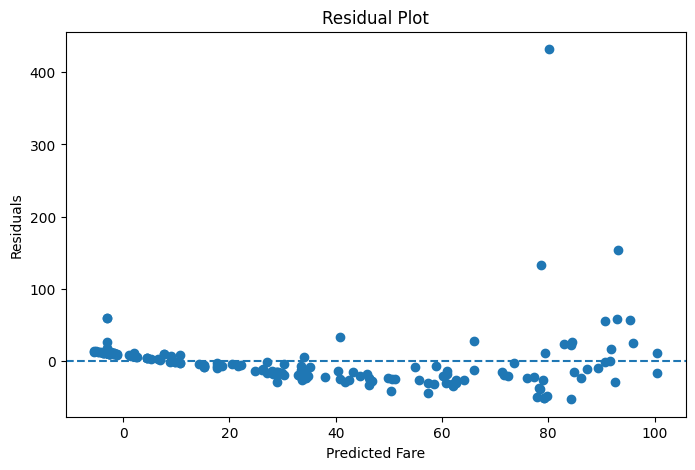

In [76]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

plt.scatter(y_pred, residuals)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel('Predicted Fare')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

**The residuals are mostly centered around zero, but their spread increases as the predicted fare increases. There are also a few large residuals at higher predicted fare values. This indicates some heteroscedasticity, meaning the residual variance is not constant across all predicted fare values**

In [77]:
final_comparison = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Accuracy': comparison_df.loc[
            comparison_df['Model'] == 'Logistic Regression', 'Accuracy'
        ].values[0],
        'Precision': comparison_df.loc[
            comparison_df['Model'] == 'Logistic Regression', 'Precision'
        ].values[0],
        'Recall': comparison_df.loc[
            comparison_df['Model'] == 'Logistic Regression', 'Recall'
        ].values[0],
        'F1': comparison_df.loc[
            comparison_df['Model'] == 'Logistic Regression', 'F1 Score'
        ].values[0],
        'AUC': comparison_df.loc[
            comparison_df['Model'] == 'Logistic Regression', 'AUC'
        ].values[0],
        'MAE': None,
        'RMSE': None,
        'R²': None,
        'Adjusted R²': None
    },
    {
        'Model': 'Decision Tree',
        'Accuracy': comparison_df.loc[
            comparison_df['Model'] == 'Decision Tree', 'Accuracy'
        ].values[0],
        'Precision': comparison_df.loc[
            comparison_df['Model'] == 'Decision Tree', 'Precision'
        ].values[0],
        'Recall': comparison_df.loc[
            comparison_df['Model'] == 'Decision Tree', 'Recall'
        ].values[0],
        'F1': comparison_df.loc[
            comparison_df['Model'] == 'Decision Tree', 'F1 Score'
        ].values[0],
        'AUC': comparison_df.loc[
            comparison_df['Model'] == 'Decision Tree', 'AUC'
        ].values[0],
        'MAE': None,
        'RMSE': None,
        'R²': None,
        'Adjusted R²': None
    },
    {
        'Model': 'Random Forest',
        'Accuracy': comparison_df.loc[
            comparison_df['Model'] == 'Random Forest', 'Accuracy'
        ].values[0],
        'Precision': comparison_df.loc[
            comparison_df['Model'] == 'Random Forest', 'Precision'
        ].values[0],
        'Recall': comparison_df.loc[
            comparison_df['Model'] == 'Random Forest', 'Recall'
        ].values[0],
        'F1': comparison_df.loc[
            comparison_df['Model'] == 'Random Forest', 'F1 Score'
        ].values[0],
        'AUC': comparison_df.loc[
            comparison_df['Model'] == 'Random Forest', 'AUC'
        ].values[0],
        'MAE': None,
        'RMSE': None,
        'R²': None,
        'Adjusted R²': None
    },
    {
        'Model': 'Linear Regression',
        'Accuracy': None,
        'Precision': None,
        'Recall': None,
        'F1': None,
        'AUC': None,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'Adjusted R²': adjusted_r2
    }
])

final_comparison

,Model,Accuracy,Precision,Recall,F1,AUC,MAE,RMSE,R²,Adjusted R²
0,Logistic Regression,0.808989,0.783333,0.691176,0.734375,0.860963,NaN,NaN,NaN,NaN
1,Decision Tree,0.808989,0.814815,0.647059,0.721311,0.856016,NaN,NaN,NaN,NaN
2,Random Forest,0.820225,0.781250,0.735294,0.757576,0.817914,NaN,NaN,NaN,NaN
3,Linear Regression,NaN,NaN,NaN,NaN,NaN,21.098604,41.702105,0.348163,0.30913


Among the three classifiers, Random Forest performed best overall, with the highest accuracy (82.02%), recall (73.53%), and F1 score (75.76%). Logistic Regression had the highest AUC (0.861) and slightly higher precision (78.33%) than Random Forest. Therefore, Random Forest is recommended because it gives a better overall balance of accuracy, recall, and F1 score. The Linear Regression model predicted fare with an MAE of 21.10, RMSE of 41.70, R² of 0.348, and Adjusted R² of 0.309.

In [78]:
full_pipeline = grid_search.best_estimator_

In [79]:
import joblib

joblib.dump(full_pipeline, 'titanic_random_forest_pipeline.joblib')

['titanic_random_forest_pipeline.joblib']

In [80]:
loaded_pipeline = joblib.load(
    'titanic_random_forest_pipeline.joblib'
)

In [88]:
raw_input = df[
    ['pclass', 'age', 'sibsp', 'parch', 'fare', 'sex', 'embarked']
].iloc[[0]]

In [89]:
prediction = loaded_pipeline.predict(raw_input)

print("Prediction:", prediction)

Prediction: [0]


In [90]:
original_prediction = full_pipeline.predict(raw_input)
loaded_prediction = loaded_pipeline.predict(raw_input)

print("Original:", original_prediction)
print("Loaded:", loaded_prediction)

Original: [0]
Loaded: [0]


In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

tree = tree_model.named_steps['classifier']

plt.figure(figsize=(15, 8))

plot_tree(
    tree,
    max_depth=3,
    feature_names=tree_model.named_steps['preprocessor'].get_feature_names_out(),
    class_names=['Not Survived', 'Survived'],
    filled=True
)

plt.show()